<a href="https://colab.research.google.com/github/Bru822/fisica-ado2/blob/main/simulacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.9 MB/s eta 0:00:00


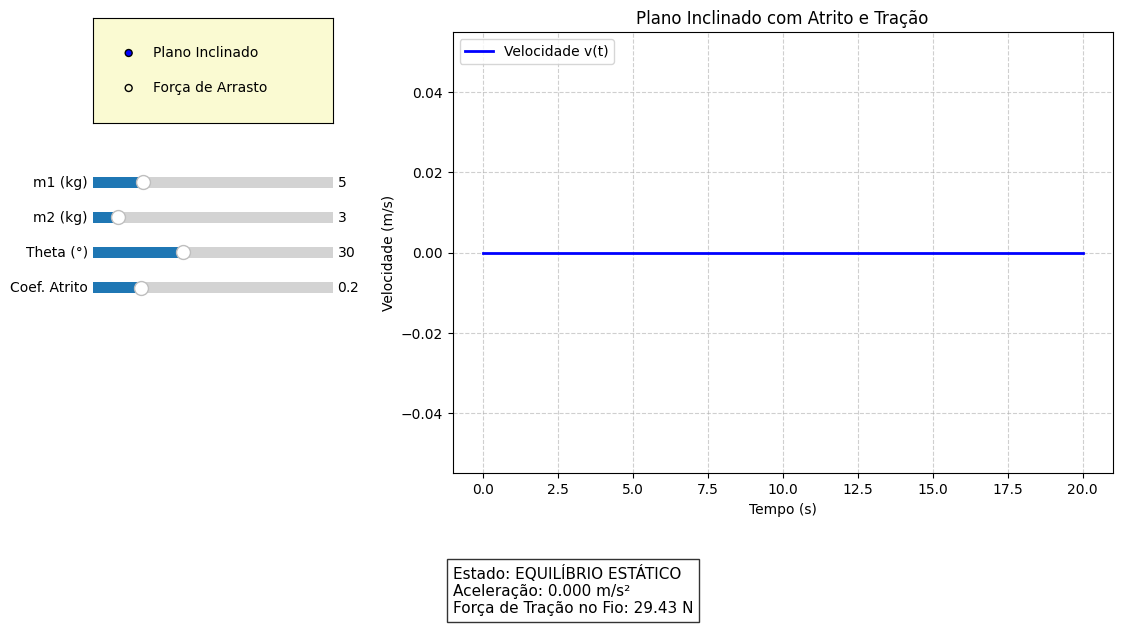

In [3]:
!pip install ipympl
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons

fig, ax = plt.subplots(figsize=(12, 7))
plt.subplots_adjust(left=0.35, bottom=0.25)
fig.canvas.manager.set_window_title('Simulacao de Sistemas Fisicos')

t = np.linspace(0, 20, 1000)
g = 9.81

ax_radio = plt.axes([0.05, 0.75, 0.2, 0.15], facecolor='lightgoldenrodyellow')
radio = RadioButtons(ax_radio, ('Plano Inclinado', 'Força de Arrasto'))

sliders_plano = {}
ax_m1 = plt.axes([0.05, 0.65, 0.2, 0.03]); sliders_plano['m1'] = Slider(ax_m1, 'm1 (kg)', 1, 20, valinit=5)
ax_m2 = plt.axes([0.05, 0.60, 0.2, 0.03]); sliders_plano['m2'] = Slider(ax_m2, 'm2 (kg)', 1, 20, valinit=3)
ax_theta = plt.axes([0.05, 0.55, 0.2, 0.03]); sliders_plano['theta'] = Slider(ax_theta, 'Theta (°)', 0, 80, valinit=30)
ax_mu = plt.axes([0.05, 0.50, 0.2, 0.03]); sliders_plano['mu'] = Slider(ax_mu, 'Coef. Atrito', 0, 1, valinit=0.2)

sliders_arrasto = {}
ax_m_arrasto = plt.axes([0.05, 0.65, 0.2, 0.03]); sliders_arrasto['m'] = Slider(ax_m_arrasto, 'm (kg)', 1, 100, valinit=70)
ax_coef = plt.axes([0.05, 0.60, 0.2, 0.03]); sliders_arrasto['coef'] = Slider(ax_coef, 'Coef. (b/c)', 0.1, 10, valinit=1.5)
ax_tipo_arrasto = plt.axes([0.05, 0.45, 0.2, 0.1], facecolor='lightgoldenrodyellow')
radio_arrasto = RadioButtons(ax_tipo_arrasto, ('Linear (Exponencial)', 'Quadrático (Tanh)'))

text_box = fig.text(0.35, 0.05, '', fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

def update(val):
    ax.clear()
    sistema = radio.value_selected

    if sistema == 'Plano Inclinado':
        for s in sliders_plano.values(): s.ax.set_visible(True)
        for s in sliders_arrasto.values(): s.ax.set_visible(False)
        radio_arrasto.ax.set_visible(False)

        m1 = sliders_plano['m1'].val
        m2 = sliders_plano['m2'].val
        theta_rad = np.radians(sliders_plano['theta'].val)
        mu = sliders_plano['mu'].val

        # 2a Lei de Newton para m1 (plano) e m2 (vertical)
        N = m1 * g * np.cos(theta_rad)
        F_motriz = m2 * g - m1 * g * np.sin(theta_rad)

        # Verifica equilibrio estatico
        if abs(F_motriz) <= mu * N:
            a = 0
            estado = "EQUILÍBRIO ESTÁTICO"
        else:
            sinal = 1 if F_motriz > 0 else -1
            a = (F_motriz - mu * N * sinal) / (m1 + m2)
            estado = "EM MOVIMENTO"

        # Equacoes do MRUV para posicao e velocidade no tempo
        v = a * t
        x = 0.5 * a * t**2
        T_tracao = m2 * (g - a)

        ax.plot(t, v, 'b-', lw=2, label='Velocidade v(t)')
        ax.set_title("Plano Inclinado com Atrito e Tração")
        ax.set_ylabel("Velocidade (m/s)")
        ax.set_xlabel("Tempo (s)")

        texto = f"Estado: {estado}\nAceleração: {a:.3f} m/s²\nForça de Tração no Fio: {T_tracao:.2f} N"

    elif sistema == 'Força de Arrasto':
        for s in sliders_plano.values(): s.ax.set_visible(False)
        for s in sliders_arrasto.values(): s.ax.set_visible(True)
        radio_arrasto.ax.set_visible(True)

        m = sliders_arrasto['m'].val
        coef = sliders_arrasto['coef'].val
        tipo = radio_arrasto.value_selected

        # Equacao de queda livre (sem resistencia do ar) para comparar
        v_livre = g * t

        if 'Linear' in tipo:
            # Formula de decaimento aerodinamico linear
            b = coef
            v_term = (m * g) / b
            tau = m / b
            v = v_term * (1 - np.exp(-t / tau))
        else:
            # Formula de decaimento quadratico com tangente hiperbolica
            c = coef
            v_term = np.sqrt((m * g) / c)
            v = v_term * np.tanh((g * t) / v_term)

        ax.plot(t, v_livre, 'r--', lw=1.5, label='Queda Livre (v = gt)')
        ax.plot(t, v, 'b-', lw=2.5, label=f'Queda com Arrasto {tipo.split()[0]}')
        ax.axhline(v_term, color='g', linestyle=':', lw=2, label=f'Vel. Terminal ({v_term:.2f} m/s)')

        ax.set_title("Queda sob Ação da Gravidade com Força de Arrasto")
        ax.set_ylabel("Velocidade (m/s)")
        ax.set_xlabel("Tempo (s)")
        ax.set_ylim(0, v_term * 1.5)

        texto = f"Massa: {m} kg | Coeficiente: {coef}\nVelocidade Terminal Calculada: {v_term:.3f} m/s"

    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)
    text_box.set_text(texto)
    fig.canvas.draw_idle()

radio.on_clicked(update)
radio_arrasto.on_clicked(update)
for s in sliders_plano.values(): s.on_changed(update)
for s in sliders_arrasto.values(): s.on_changed(update)

update(None)
plt.show()